<a href="https://colab.research.google.com/github/ahmadisyraf39/palm-oil-insights/blob/main/palm_oil_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Malaysian Palm Oil Price & Production Insights**

Do rainfall and production affect palm oil prices, and can next month's price be forecast? This notebook collects, cleans and analyses public data from the World Bank, MPOB and Open-Meteo.

**Step 1: Setup**

Connect Google Drive to access the data files, and import pandas for data handling and requests for downloading data from APIs.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

folder = "/content/drive/MyDrive/palm_oil_project/"

import pandas as pd
import requests
print("Ready!", pd.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready! 2.2.3


**Step 2: Palm oil prices**

Load monthly palm oil prices (USD/tonne) from the World Bank Pink Sheet, clean the dates, and keep data from 2015 onward.

In [20]:
f = folder + "CMO-Historical-Data-Monthly.xlsx"

# 1. Read the sheet with no headers so we can find which row holds the column names
raw_price = pd.read_excel(f, sheet_name="Monthly Prices", header=None)

# 2. Find the row number that contains the text "Palm oil"
hdr = raw_price.index[raw_price.apply(lambda r: r.astype(str).str.contains("Palm oil").any(), axis=1)][0]
print("Header row is:", hdr)

# 3. Read the sheet again, using that row as column names
price = pd.read_excel(f, sheet_name="Monthly Prices", header=hdr)
price.columns = price.columns.astype(str).str.strip()   # remove stray spaces from names

# 4. Keep only the date column and the palm oil column
price = price.rename(columns={price.columns[0]: "month"})
price = price[["month", "Palm oil"]]

# 5. Keep only rows whose month looks like "2015M01"
price = price[price["month"].astype(str).str.match(r"\d{4}M\d{2}")].copy()

# 6. Turn "2015M01" into a real date: "2015-01-01"
price["date"] = pd.to_datetime(price["month"].str.replace("M", "-") + "-01")

# 7. Tidy up: rename the column and make sure prices are numbers
price = price[["date", "Palm oil"]].rename(columns={"Palm oil": "price_usd"})
price["price_usd"] = pd.to_numeric(price["price_usd"], errors="coerce")

# 8. Keep 2015 onward
price = price[price["date"] >= "2015-01-01"]

# print the first (n) rows
display(price.head(10))

# print number of rows and columns
print(price.shape)

# print the last (n) rows
display(price.tail())

Header row is: 4


,date,price_usd
661,2015-01-01,720
662,2015-02-01,723
663,2015-03-01,699
664,2015-04-01,683
665,2015-05-01,697
666,2015-06-01,706
667,2015-07-01,680
668,2015-08-01,601
669,2015-09-01,600
670,2015-10-01,637


(140, 2)


,date,price_usd
796,2026-04-01,1146
797,2026-05-01,1136
798,2026-06-01,1104
799,2026-07-01,1101
800,2026-08-01,1117


**Step 3: Rainfall**

Download daily rainfall for Sandakan, Sabah, from the Open-Meteo API and sum it per month, since palm oil yields respond to rainfall with a delay.

In [21]:
url = ("https://archive-api.open-meteo.com/v1/archive"
       "?latitude=5.84&longitude=118.12"          # Sandakan, Sabah (a major palm oil area)
       "&start_date=2015-01-01&end_date=2026-08-31"
       "&daily=precipitation_sum"                  # total rain per day, in mm
       "&timezone=Asia/Kuala_Lumpur")

response = requests.get(url)       # ask the API for data
d = response.json()["daily"]       # JSON is a common data format; take the "daily" part

rain = pd.DataFrame({"date": pd.to_datetime(d["time"]), "rain_mm": d["precipitation_sum"]})
print(rain.shape)
display(rain.head())

rain = rain.resample("MS", on="date").sum().reset_index()
print(rain.shape)
display(rain.head())

(4261, 2)


,date,rain_mm
0,2015-01-01,49.3
1,2015-01-02,39.7
2,2015-01-03,9.4
3,2015-01-04,8.5
4,2015-01-05,4.6


(140, 2)


,date,rain_mm
0,2015-01-01,388.9
1,2015-02-01,91.2
2,2015-03-01,75.3
3,2015-04-01,139.3
4,2015-05-01,120.0


**Step 4: Merge and check**

Combine prices and rainfall by month, check for missing values, and save the clean dataset.

In [22]:
df = price.merge(rain, on="date")
print(df.shape)
display(df.head())

print(df.isna().sum())         # count missing values per column
print(df["date"].min(), "to", df["date"].max())
display(df.describe())                  # min, max, average of each column

df.to_csv(folder + "palm_oil_prices_and_rainfall.csv", index=False)

(140, 3)


,date,price_usd,rain_mm
0,2015-01-01,720,388.9
1,2015-02-01,723,91.2
2,2015-03-01,699,75.3
3,2015-04-01,683,139.3
4,2015-05-01,697,120.0


date         0
price_usd    0
rain_mm      0
dtype: int64
2015-01-01 00:00:00 to 2026-08-01 00:00:00


,date,price_usd,rain_mm
count,140,140.000000,140.000000
mean,2020-10-15 19:53:08.571428608,868.664286,257.547857
min,2015-01-01 00:00:00,535.000000,50.200000
25%,2017-11-23 12:00:00,696.250000,168.650000
50%,2020-10-16 12:00:00,815.500000,251.800000
75%,2023-09-08 12:00:00,1007.750000,330.950000
max,2026-08-01 00:00:00,1777.000000,670.400000
std,NaN,243.262082,117.039545


**Step 5: MPOB production and stocks**

Add Malaysian crude palm oil production and total palm oil closing stocks from MPOB, matched by month. Gaps in the production series are backfilled from MPOB's yearly Summary reports.

In [23]:
folder = "/content/drive/MyDrive/palm_oil_project/"

# MPOB monthly data via palmoileconomics.com (long format: one row per month per indicator)
raw = pd.read_csv(folder + "mpob_raw.csv")

print(raw.shape)
print(raw["indicator"].unique())
display(raw.head())

(1694, 6)
['cpo_stock' 'processed_po_stock' 'total_po_stock' 'cpko_production'
 'cpo_import' 'cpo_production' 'pk_production' 'pkc_production'
 'pko_stock' 'po_export' 'po_import' 'ffb_price' 'biodiesel_export'
 'oleochemical_export' 'pkc_export' 'pko_export']


,month,indicator,value,unit,revision,source
0,2000-01-01,cpo_stock,629381.0,tonnes,bepi,Malaysian Palm Oil Board (MPOB) monthly indust...
1,2000-01-01,processed_po_stock,330481.0,tonnes,bepi,Malaysian Palm Oil Board (MPOB) monthly indust...
2,2000-01-01,total_po_stock,959862.0,tonnes,bepi,Malaysian Palm Oil Board (MPOB) monthly indust...
3,2000-02-01,cpo_stock,574161.0,tonnes,bepi,Malaysian Palm Oil Board (MPOB) monthly indust...
4,2000-02-01,processed_po_stock,333590.0,tonnes,bepi,Malaysian Palm Oil Board (MPOB) monthly indust...


In [24]:
# Keep the 2 indicators and reshape to one row per month
mpob = raw[raw["indicator"].isin(["cpo_production", "total_po_stock"])]
mpob = mpob.pivot_table(index="month", columns="indicator", values="value", aggfunc="last").reset_index()
mpob = mpob.rename(columns={"month": "date", "cpo_production": "production_t", "total_po_stock": "stocks_t"})
mpob["date"] = pd.to_datetime(mpob["date"])
mpob = mpob[mpob["date"] >= "2015-01-01"]

print("Missing production months:", mpob["production_t"].isna().sum())
display(mpob.tail())

Missing production months: 76


indicator,date,production_t,stocks_t
315,2026-04-01,1629801.0,2308944.0
316,2026-05-01,1516327.0,2427943.0
317,2026-06-01,1638796.0,2543830.0
318,2026-07-01,1792596.0,2627898.0
319,2026-08-01,1817499.0,2824488.0


In [25]:
fill = pd.read_csv(folder + "production_backfill.csv", parse_dates=["date"])

mpob = mpob.set_index("date")
mpob["production_t"] = mpob["production_t"].fillna(fill.set_index("date")["production_t"])
mpob = mpob.reset_index()

print("Missing production months after backfill:", mpob["production_t"].isna().sum())
mpob.to_csv(folder + "mpob_production.csv", index=False)

Missing production months after backfill: 0


In [26]:
# Drop MPOB columns if this cell was run before, so rerunning never creates _x/_y duplicates
df = df.drop(columns=["production_t", "stocks_t"], errors="ignore")

df = df.merge(mpob, on="date", how="left")
df["rain_mm"] = df["rain_mm"].round(1)

print(df.shape)
print(df.isna().sum())
df.to_csv(folder + "palm_oil_monthly.csv", index=False)
display(df.tail())

(140, 5)
date            0
price_usd       0
rain_mm         0
production_t    0
stocks_t        0
dtype: int64


,date,price_usd,rain_mm,production_t,stocks_t
135,2026-04-01,1146,50.2,1629801.0,2308944.0
136,2026-05-01,1136,143.5,1516327.0,2427943.0
137,2026-06-01,1104,234.5,1638796.0,2543830.0
138,2026-07-01,1101,172.7,1792596.0,2627898.0
139,2026-08-01,1117,106.8,1817499.0,2824488.0


**Step 6: Load the clean dataset**

Load the merged monthly dataset (price, rainfall, production, stocks) saved in Step 5, and set up a chart style used for all charts below.

In [27]:
import matplotlib.pyplot as plt

df = pd.read_csv(folder + "palm_oil_monthly.csv", parse_dates=["date"])
df["month_num"] = df["date"].dt.month      # 1 = Jan, 12 = Dec

print(df.shape)
print("Missing values:", df.isna().sum().sum())

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
BLUE = "#2a78b5"

def tidy(ax, title, xlabel, ylabel):
    """Apply one clean style to every chart."""
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)                 # grid lines behind the bars
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False) # remove the box around the chart

(140, 6)
Missing values: 0


**Step 7: Seasonal production pattern**

Average CPO production for each calendar month, to see whether output follows a yearly cycle.

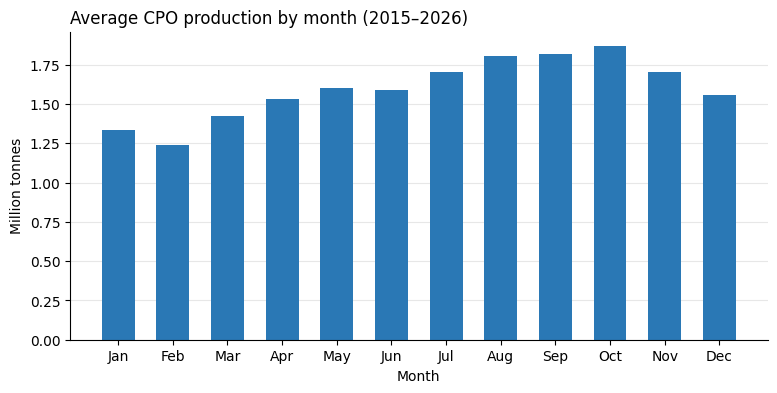

Peak month: Oct | Lowest month: Feb


In [28]:
season = df.groupby("month_num")["production_t"].mean() / 1e6   # million tonnes

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(MONTHS, season.values, color=BLUE, width=0.6)
tidy(ax, "Average CPO production by month (2015–2026)", "Month", "Million tonnes")
plt.show()

print("Peak month:", MONTHS[season.idxmax() - 1], "| Lowest month:", MONTHS[season.idxmin() - 1])

**Step 8: Rainfall lag effect**

Correlation between monthly production and rainfall 0–12 months earlier, to find how long rainfall takes to affect output.

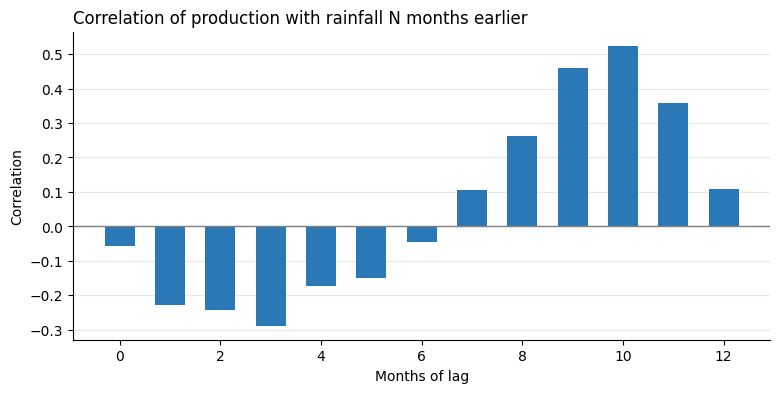

Strongest link: rainfall 10 months earlier (r = 0.52)


In [29]:
lags = range(0, 13)
corr = [df["production_t"].corr(df["rain_mm"].shift(lag)) for lag in lags]
best_lag = max(lags, key=lambda lag: corr[lag])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(list(lags), corr, color=BLUE, width=0.6)
ax.axhline(0, color="gray", linewidth=1)
tidy(ax, "Correlation of production with rainfall N months earlier", "Months of lag", "Correlation")
plt.show()

print(f"Strongest link: rainfall {best_lag} months earlier (r = {corr[best_lag]:.2f})")

**Step 9: Stocks vs next month's price**

Compare palm oil closing stocks with the following month's price, to test whether oversupply is linked to lower prices.

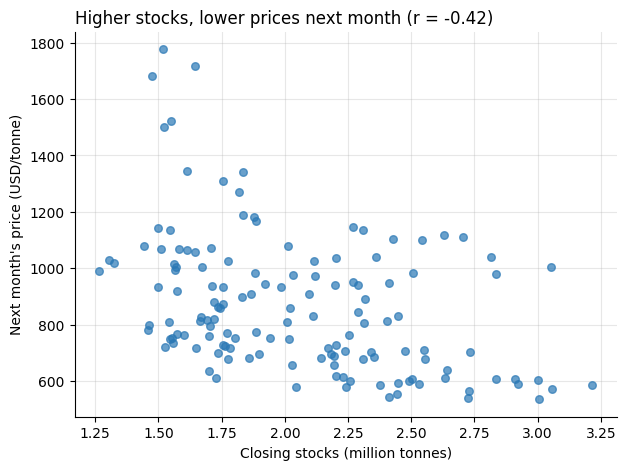

In [30]:
next_price = df["price_usd"].shift(-1)          # the price one month later
r = df["stocks_t"].corr(next_price)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["stocks_t"] / 1e6, next_price, color=BLUE, s=30, alpha=0.7)
tidy(ax, f"Higher stocks, lower prices next month (r = {r:.2f})",
     "Closing stocks (million tonnes)", "Next month's price (USD/tonne)")
ax.grid(axis="x", alpha=0.3)
plt.show()

**Step 10: Feature engineering**

Build model inputs using only information available before each month (last month's price change, stocks, production and lagged rainfall). The model predicts the price change from last month, which is then added to last month's price.

In [31]:
df["price_lag1"]      = df["price_usd"].shift(1)          # last month's price
df["change_lag1"]     = df["price_usd"].diff().shift(1)   # last month's price change
df["stocks_lag1"]     = df["stocks_t"].shift(1)
df["stocks_chg_lag1"] = df["stocks_t"].diff().shift(1)    # did stocks rise or fall last month?
df["prod_lag1"]       = df["production_t"].shift(1)
df["rain_lag"]        = df["rain_mm"].shift(best_lag)     # the lag found in Step 8

df["target_change"] = df["price_usd"] - df["price_lag1"]  # what we predict

feats = ["change_lag1", "stocks_lag1", "stocks_chg_lag1", "prod_lag1", "rain_lag", "month_num"]
data = df.dropna(subset=feats + ["target_change"])

train = data[data["date"] < "2024-01-01"]
test  = data[data["date"] >= "2024-01-01"].copy()
print("Train months:", len(train), "| Test months:", len(test))

Train months: 98 | Test months: 32


**Step 11: Model comparison**

Compare a naive baseline (next month = this month) with Linear Regression and Random Forest, using mean absolute error (MAE) on 2024–2026.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

linear = LinearRegression().fit(train[feats], train["target_change"])
forest = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)
forest.fit(train[feats], train["target_change"])

test["pred_naive"]  = test["price_lag1"]
test["pred_linear"] = test["price_lag1"] + linear.predict(test[feats])
test["pred_forest"] = test["price_lag1"] + forest.predict(test[feats])

results = pd.DataFrame({
    "Model": ["Naive baseline", "Linear Regression", "Random Forest"],
    "MAE (USD/tonne)": [mean_absolute_error(test["price_usd"], test[c])
                        for c in ["pred_naive", "pred_linear", "pred_forest"]],
})
naive_mae = results.loc[0, "MAE (USD/tonne)"]
results["vs baseline"] = (1 - results["MAE (USD/tonne)"] / naive_mae).map("{:.1%}".format)
results["MAE (USD/tonne)"] = results["MAE (USD/tonne)"].round(1)
display(results)

,Model,MAE (USD/tonne),vs baseline
0,Naive baseline,38.8,0.0%
1,Linear Regression,35.8,7.7%
2,Random Forest,35.1,9.7%


**Step 12: Forecast vs actual, and feature importance**

Plot the Random Forest forecast against actual prices for the test period, and show which inputs the model relied on most.

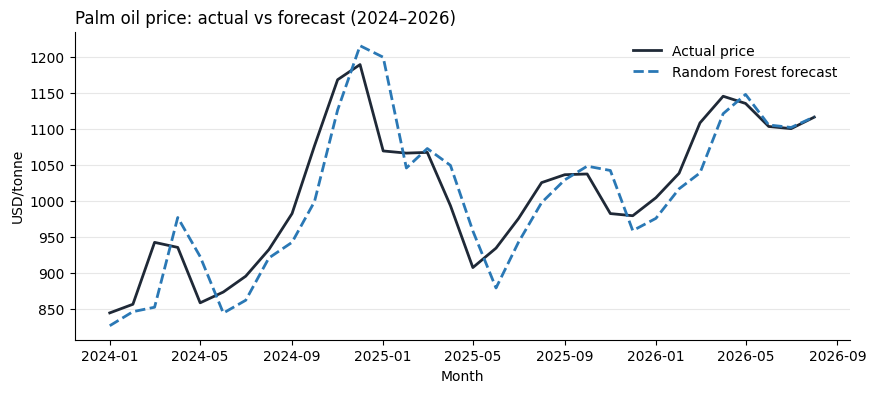

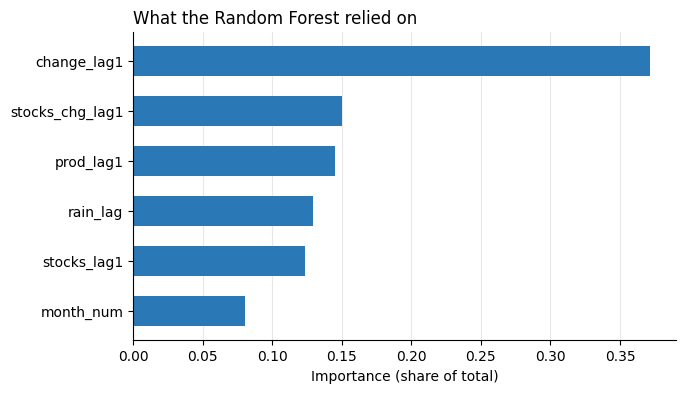

In [33]:
# Chart 1: actual vs forecast
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test["date"], test["price_usd"], color="#1f2937", linewidth=2, label="Actual price")
ax.plot(test["date"], test["pred_forest"], color=BLUE, linewidth=2, linestyle="--", label="Random Forest forecast")
tidy(ax, "Palm oil price: actual vs forecast (2024–2026)", "Month", "USD/tonne")
ax.legend(frameon=False)
plt.show()

# Chart 2: feature importance
importance = pd.Series(forest.feature_importances_, index=feats).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
tidy(ax, "What the Random Forest relied on", "Importance (share of total)", "")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", visible=False)
plt.show()

In [34]:
forecast = test[["date", "price_usd", "pred_naive", "pred_linear", "pred_forest"]].round(1)
forecast.to_csv(folder + "forecast.csv", index=False)
display(forecast.tail())

,date,price_usd,pred_naive,pred_linear,pred_forest
135,2026-04-01,1146,1109.0,1152.0,1121.8
136,2026-05-01,1136,1146.0,1159.3,1148.6
137,2026-06-01,1104,1136.0,1131.3,1106.1
138,2026-07-01,1101,1104.0,1096.6,1102.6
139,2026-08-01,1117,1101.0,1103.1,1117.4


In [35]:
seasonal_diff = (season.max() / season.min() - 1) * 100
mae = results.set_index("Model")["MAE (USD/tonne)"]
improvement = (1 - mae["Random Forest"] / mae["Naive baseline"]) * 100

print(f"1. Seasonal difference:        {seasonal_diff:.0f}%")
print(f"2. Rainfall correlation (r):   {corr[best_lag]:.2f} at {best_lag} months")
print(f"3. Stocks vs price (r):        {r:.2f}")
print(f"4. Forecast improvement:       {improvement:.1f}%")
print(f"   Random Forest MAE:          USD {mae['Random Forest']:.1f}")
print(f"   Naive baseline MAE:         USD {mae['Naive baseline']:.1f}")

1. Seasonal difference:        51%
2. Rainfall correlation (r):   0.52 at 10 months
3. Stocks vs price (r):        -0.42
4. Forecast improvement:       9.5%
   Random Forest MAE:          USD 35.1
   Naive baseline MAE:         USD 38.8


**Key insights**

1. **Strong seasonality:** CPO production is lowest in February and peaks in October, a difference of about 51%.
2. **Rainfall acts with a delay:** production is most strongly linked to rainfall about 10 months earlier (r = 0.52), consistent with the long development time of oil palm fruit bunches. Part of this may reflect shared seasonality.
3. **Stocks weigh on prices:** higher closing stocks are associated with lower prices the following month (r = −0.42).

**Forecast:** a Random Forest predicting monthly price changes reduced error by 9.5% versus a naive baseline (MAE USD 35.1 vs USD 38.8 per tonne, 2024–2026 test period). The gain is modest, as expected for commodity prices, which are driven by many global factors not included here.

**Step 13: Upload to Azure Blob Storage**

Upload the final datasets to Azure Blob Storage (processed/ folder), which the Power BI dashboard reads from. The connection string is stored in Colab Secrets, not in the code.

In [36]:
!pip install -q azure-storage-blob

from azure.storage.blob import BlobServiceClient
from google.colab import userdata

conn_str = userdata.get("AZURE_CONN_STR")          # read the secret, never hard-coded
container = BlobServiceClient.from_connection_string(conn_str).get_container_client("palm-oil-data")

for name in ["palm_oil_monthly.csv", "forecast.csv"]:
    with open(folder + name, "rb") as f:
        container.upload_blob(f"processed/{name}", f, overwrite=True)
    print(f"Uploaded processed/{name}")

Uploaded processed/palm_oil_monthly.csv
Uploaded processed/forecast.csv
